## 1. Installation

In [1]:
!apt-get update -qq && apt-get install -y -qq tesseract-ocr tesseract-ocr-deu tesseract-ocr-fra
!pip install -q pytesseract

import pytesseract
from importlib.metadata import version
print("pytesseract version :", version("pytesseract"))
print("tesseract binaire   :", pytesseract.get_tesseract_version())

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-deu.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-deu_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-deu (1:4.00~git30-7274cfa-1.1) ...
Selecting previously unselected package tesseract-ocr-fra.
Preparing to unpack .../tesseract-ocr-fra_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-deu (1:4.00~git30-7274cfa-1.1) ...
pytesseract version : 0.3.13
tesseract binaire   : 4.1.1


## 2. Verifier le dataset Kaggle

Sur Kaggle, les fichiers d'un dataset ajoute au notebook sont montes en lecture seule sous `/kaggle/input/<nom-du-dataset>/`. On liste le contenu pour confirmer le chemin exact avant de continuer (utile si le PDF est dans un sous-dossier).

In [2]:
import os

# Etape 1 : lister tous les datasets disponibles sous /kaggle/input
print("Datasets disponibles dans /kaggle/input :")
for name in os.listdir("/kaggle/input"):
    print(" -", name)

Datasets disponibles dans /kaggle/input :
 - datasets


In [3]:
# Etape 2 : exploration recursive complete pour trouver tous les PDF,
# quelle que soit la profondeur des sous-dossiers
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".pdf"):
            print(os.path.join(root, f))

/kaggle/input/datasets/hasnaasaadi/my-dataset4/loan_0001.pdf


## 3. Configuration des parametres de lecture

Contrairement a EasyOCR/PaddleOCR, Tesseract n'a pas d'objet "Reader" persistant : chaque appel `image_to_data`
prend directement la langue et les options en parametre (`lang`, `config`).

**Langue** : `deu+eng` combine les deux modeles (comme pour EasyOCR, plusieurs langues sont utilisables ensemble),
utile si le document mixe des mentions en anglais dans un formulaire allemand.

**PSM (Page Segmentation Mode)** : `--psm 6` suppose un bloc de texte uniforme (adapte a un formulaire dense),
`--psm 3` (par defaut) fait une segmentation automatique complete de la page. On garde `--psm 6` ici car nos PDF
sont des formulaires structures en lignes label/valeur.

In [4]:
LANG = "deu+eng"
TESS_CONFIG = "--oem 3 --psm 11"

print("Langue Tesseract :", LANG)
print("Config Tesseract :", TESS_CONFIG)

Langue Tesseract : deu+eng
Config Tesseract : --oem 3 --psm 11


## 4. Lecture du PDF et conversion en images

Chemin adapte a Kaggle : `/kaggle/input/<dataset>/...` pour la lecture (lecture seule).

Comme EasyOCR et PaddleOCR, Tesseract travaille sur des images. Chaque page du PDF est donc convertie en image
avec `pdf2image`, qui s'appuie sur le binaire `poppler` (installe via `apt-get` dans la cellule suivante, car
absent par defaut de certaines images Kaggle) avant de lancer l'OCR.

In [6]:
# Adapte le nom de fichier si besoin, d'apres la sortie de la cellule 2
DATASET_DIR = "/kaggle/input/datasets/hasnaasaadi/my-dataset4"
PDF_PATH = os.path.join(DATASET_DIR, "loan_0001.pdf")

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# pdf2image s'appuie sur le binaire "poppler" (pdfinfo, pdftoppm), absent par defaut
# de certaines images Kaggle -> on l'installe via apt avant d'utiliser pdf2image.
!apt-get install -y -qq poppler-utils
!pip install -q pdf2image

from pdf2image import convert_from_path

pages = convert_from_path(PDF_PATH, dpi=300)  # 300 DPI recommande pour Tesseract (meilleure precision)
image_paths = []
for i, page in enumerate(pages):
    img_path = os.path.join(OUTPUT_DIR, f"page_{i+1}.png")
    page.save(img_path, "PNG")
    image_paths.append(img_path)

print("Pages converties en images :", image_paths)

Pages converties en images : ['/kaggle/working/page_1.png', '/kaggle/working/page_2.png']


## 5. Execution de l'OCR

`pytesseract.image_to_data(...)` renvoie, au niveau du mot, les coordonnees (`left`, `top`, `width`, `height`),
le texte et la confiance. On regroupe ensuite les mots par ligne (`block_num`, `par_num`, `line_num`) pour
reconstruire des lignes completes, dans la meme logique que les autres moteurs (`all_results`).

In [8]:
from PIL import Image
from pytesseract import Output

all_words = []  # mots individuels avec leur position (utile pour la reconstruction de tableau)

for page_num, img_path in enumerate(image_paths, start=1):
    img = Image.open(img_path)
    data = pytesseract.image_to_data(img, lang=LANG, config=TESS_CONFIG, output_type=Output.DICT)

    n_words = 0
    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        conf = int(data["conf"][i])
        if text == "" or conf < 0:
            continue
        all_words.append({
            "page": page_num,
            "text": text,
            "confidence": conf / 100,
            "left": data["left"][i],
            "top": data["top"][i],
            "width": data["width"][i],
            "height": data["height"][i],
            "line_key": (data["block_num"][i], data["par_num"][i], data["line_num"][i]),
        })
        n_words += 1

    print(f"Page {page_num} : {n_words} mots detectes")

print("\nTotal mots detectes :", len(all_words))

Page 1 : 155 mots detectes
Page 2 : 6 mots detectes

Total mots detectes : 161


## 6. Regroupement en lignes (comme les autres moteurs)

On regroupe les mots partageant la meme `line_key` pour obtenir des lignes de texte completes avec une bbox
englobante, dans la meme structure `all_results` (page, bbox, texte, confiance) que EasyOCR/PaddleOCR.

In [9]:
from collections import defaultdict

lines_by_key = defaultdict(list)
for w in all_words:
    lines_by_key[(w["page"], w["line_key"])].append(w)

all_results = []
for (page_num, line_key), words in lines_by_key.items():
    words_sorted = sorted(words, key=lambda w: w["left"])
    text = " ".join(w["text"] for w in words_sorted)
    x0 = min(w["left"] for w in words_sorted)
    y0 = min(w["top"] for w in words_sorted)
    x1 = max(w["left"] + w["width"] for w in words_sorted)
    y1 = max(w["top"] + w["height"] for w in words_sorted)
    conf_moyenne = sum(w["confidence"] for w in words_sorted) / len(words_sorted)

    all_results.append({
        "page": page_num,
        "bbox": [[x0, y0], [x1, y0], [x1, y1], [x0, y1]],
        "text": text,
        "confidence": conf_moyenne,
        "words": words_sorted,  # conserve pour la reconstruction de tableau (etape suivante)
    })

# Trier les lignes par page puis par position verticale (haut -> bas)
all_results.sort(key=lambda r: (r["page"], r["bbox"][0][1]))

print("Total lignes reconstruites :", len(all_results))

Total lignes reconstruites : 52


## 7. Export Markdown avec reconstruction de tableau (heuristique)

Tesseract ne detecte pas nativement les tableaux (contrairement a Docling). On applique une heuristique simple :
sur chaque ligne, si un grand espace horizontal separe deux groupes de mots (`GAP_THRESHOLD_PX`), on considere
qu'il s'agit d'une paire `label | valeur` (frequent dans un formulaire de credit) et on l'exporte comme une ligne
de tableau Markdown. Sinon, la ligne est exportee comme texte simple.

**Limite** : c'est une approximation base sur l'espacement, pas une vraie detection de structure de tableau.
Elle fonctionne bien sur des formulaires a 2 colonnes bien alignees, moins bien sur des tableaux plus complexes.

In [10]:
GAP_THRESHOLD_PX = 40  # ecart horizontal (en pixels a 300 DPI) au-dela duquel on separe deux colonnes

def split_line_into_columns(words_sorted, gap_threshold=GAP_THRESHOLD_PX):
    columns = [[words_sorted[0]]]
    for prev, curr in zip(words_sorted, words_sorted[1:]):
        gap = curr["left"] - (prev["left"] + prev["width"])
        if gap > gap_threshold:
            columns.append([curr])
        else:
            columns[-1].append(curr)
    return [" ".join(w["text"] for w in col) for col in columns]

md_text = ""
current_page = None
in_table = False

for r in all_results:
    if r["page"] != current_page:
        current_page = r["page"]
        md_text += f"\n\n## Page {current_page}\n\n"
        in_table = False

    columns = split_line_into_columns(r["words"])

    if len(columns) == 2:
        # Ligne label / valeur -> export en ligne de tableau Markdown
        if not in_table:
            md_text += f"| {columns[0]} | {columns[1]} |\n"
            md_text += "|---|---|\n"
            in_table = True
        else:
            md_text += f"| {columns[0]} | {columns[1]} |\n"
    else:
        # Ligne simple (titre, phrase...) -> texte normal
        in_table = False
        md_text += r["text"] + "\n"

print(md_text)



## Page 1

Loan Application for a Commercial Real Estate
Loan - Company Profile
1. Applicant
Company Name
Söding GmbH & Co. KGaA UG
Limited Partnership (KG)
Legal Form
Date of Incorporation
01/12/2006
Falk-Textor-Weg 160, 86608 Gransee, Germany
Business Address
Commercial Register Number / Court
HRB 977141 / Gransee Local Court
VAT ID / Tax Number
DE681242882
2. Financial Request / Property Description
Type of Property
Office and Commercial Building
Werden Center Gransee
Property Name
Laszlo-Hiller-Allee 29, 79030 Gransee, Germany
Adress
Purchase Price / Construction Costs
€1,337,000
Desired Financing Amount
€944,000
Purpose of Use
Modernization
Equity Contribution
€393,000
Year of Construction
1990
Total Area
3,133 m?
3. Financing Proposal
Desired Loan Amount
€944,000
Term
25 years
Preferred Installment Amount
€4,100 per month
Interest Rate
Variable
Early Repayment Desired?
[ ] yes [x] no
Public Subsidies Applied For?
[x] yes [] no
4. Declaration & Signature
| hereby confirm the acc

In [11]:
# Sauvegarde en Markdown dans /kaggle/working (seul dossier ecriture autorisee sur Kaggle)
md_out_path = os.path.join(OUTPUT_DIR, "loan_0001_tesseract.md")

with open(md_out_path, "w", encoding="utf-8") as f:
    f.write(md_text)

print("Sauvegarde OK :", md_out_path)

Sauvegarde OK : /kaggle/working/loan_0001_tesseract.md


## 8. Export JSON

Le JSON complet (texte + positions + confiance), utile pour un traitement automatique en aval — meme logique
que pour les autres moteurs.

In [12]:
import json

json_ready = [
    {
        "page": r["page"],
        "text": r["text"],
        "confidence": float(r["confidence"]),
        "bbox": r["bbox"],
    }
    for r in all_results
]

json_out_path = os.path.join(OUTPUT_DIR, "loan_0001_tesseract.json")
with open(json_out_path, "w", encoding="utf-8") as f:
    json.dump(json_ready, f, ensure_ascii=False, indent=2)

print("JSON sauvegarde :", json_out_path)

JSON sauvegarde : /kaggle/working/loan_0001_tesseract.json


## 9. Parcourir les elements avec leurs positions (bounding boxes)

In [13]:
for r in all_results:
    print(f"[page {r['page']}] conf {r['confidence']:.2f} | bbox {r['bbox']}")
    print("   ", r["text"][:90])

[page 1] conf 0.96 | bbox [[244, 258], [2087, 258], [2087, 338], [244, 338]]
    Loan Application for a Commercial Real Estate
[page 1] conf 0.93 | bbox [[244, 358], [1170, 358], [1170, 438], [244, 438]]
    Loan - Company Profile
[page 1] conf 0.96 | bbox [[240, 559], [519, 559], [519, 606], [240, 606]]
    1. Applicant
[page 1] conf 0.96 | bbox [[263, 676], [530, 676], [530, 712], [263, 712]]
    Company Name
[page 1] conf 0.94 | bbox [[1089, 676], [1602, 676], [1602, 712], [1089, 712]]
    Söding GmbH & Co. KGaA UG
[page 1] conf 0.96 | bbox [[1090, 767], [1498, 767], [1498, 803], [1090, 803]]
    Limited Partnership (KG)
[page 1] conf 0.96 | bbox [[264, 768], [448, 768], [448, 803], [264, 803]]
    Legal Form
[page 1] conf 0.96 | bbox [[264, 859], [608, 859], [608, 895], [264, 895]]
    Date of Incorporation
[page 1] conf 0.96 | bbox [[1089, 860], [1273, 860], [1273, 888], [1089, 888]]
    01/12/2006
[page 1] conf 0.94 | bbox [[1090, 951], [1893, 951], [1893, 987], [1090, 987]]
    

## 10. Visualiser les detections sur l'image

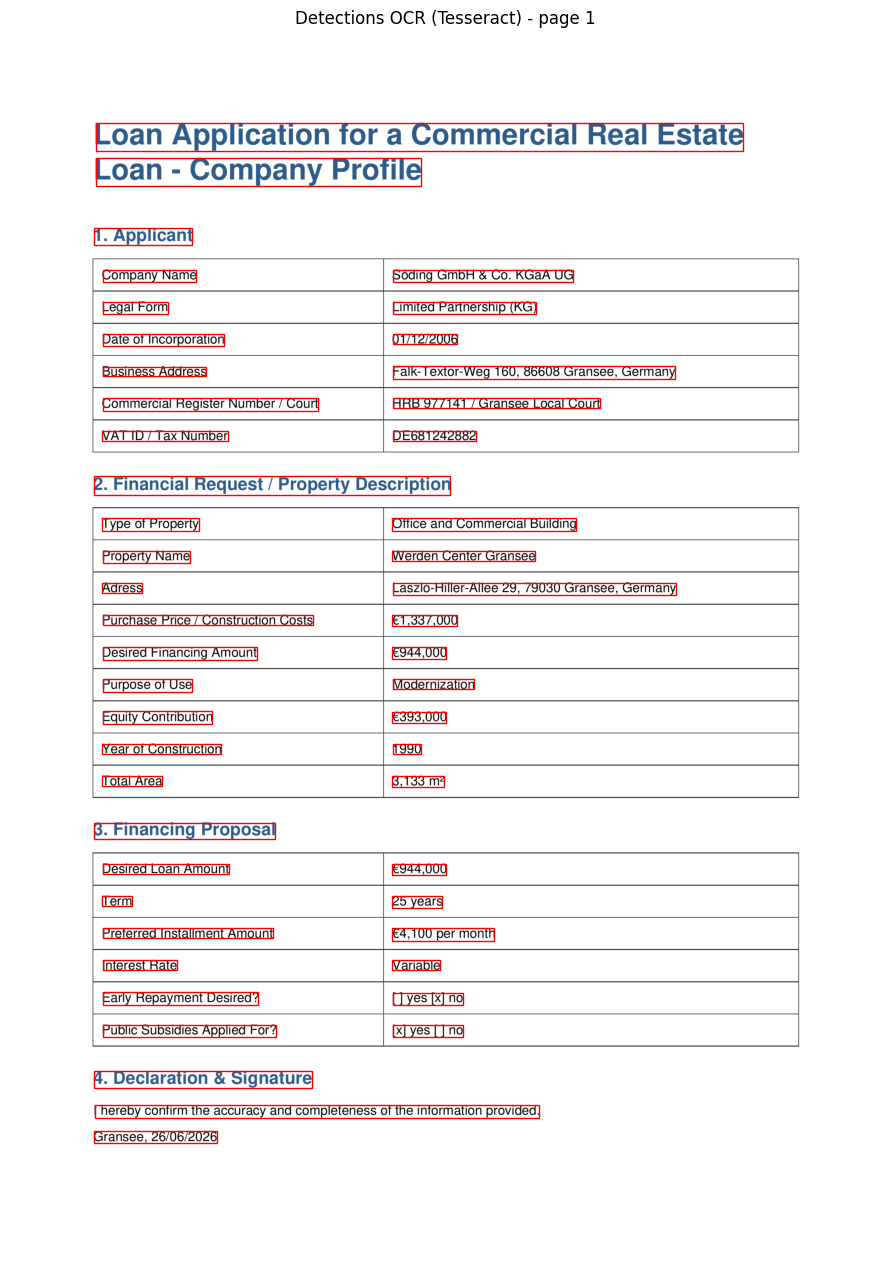

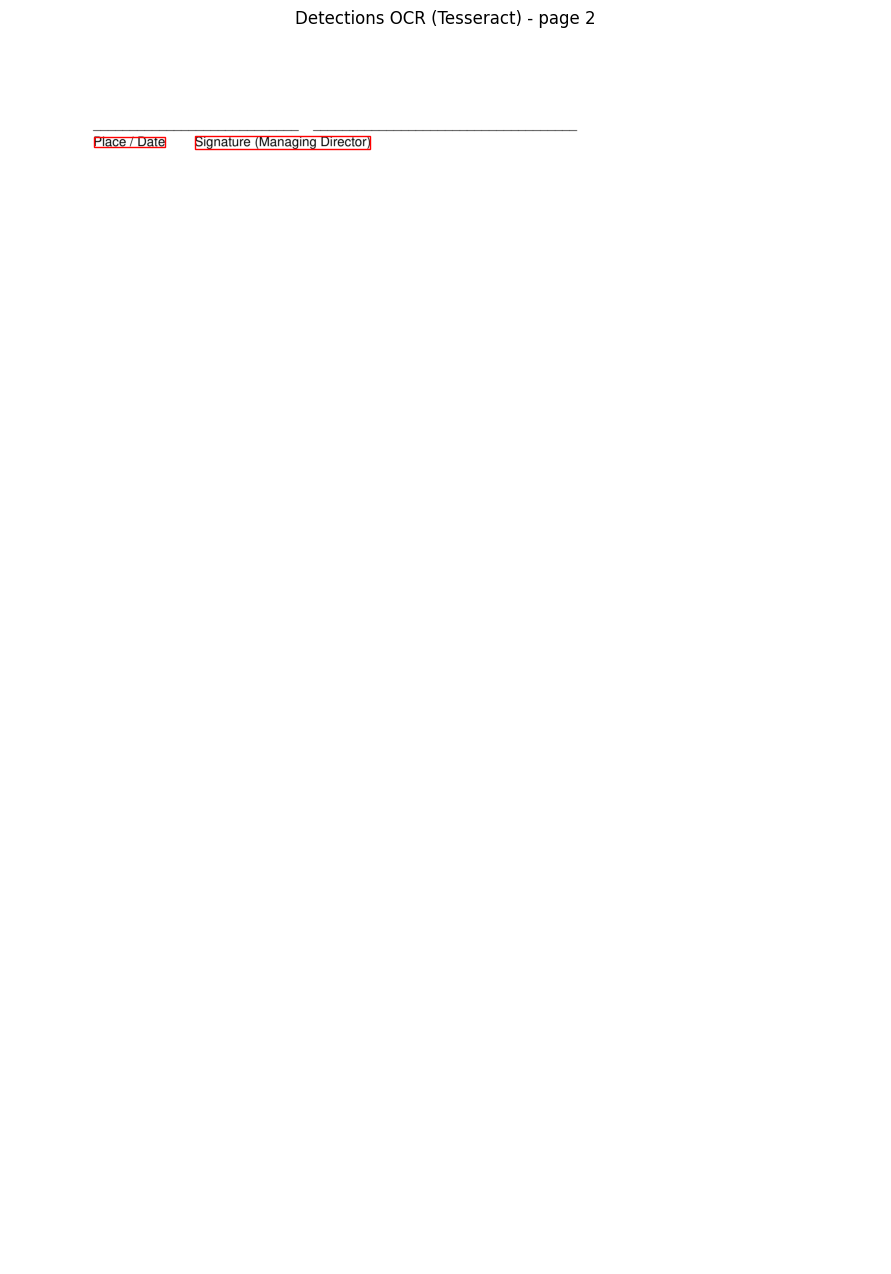

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

for page_num, img_path in enumerate(image_paths, start=1):
    img = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(img)

    for r in all_results:
        if r["page"] != page_num:
            continue
        (x0, y0), _, (x1, y1), _ = r["bbox"]
        rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=1, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

    ax.set_title(f"Detections OCR (Tesseract) - page {page_num}")
    ax.axis("off")
    plt.show()

## 11. Recuperer les resultats sous forme de tableau pandas

## Resume des chemins Kaggle

- Lecture (input, lecture seule) : `/kaggle/input/<dataset>/...`
- Ecriture (output) : `/kaggle/working/...` -> c'est ce dossier qui apparait ensuite dans l'onglet "Output" du notebook Kaggle une fois execute/commit

## Resume des parametres principaux

- `LANG = "deu+eng"` : langues combinees (comme EasyOCR, contrairement a PaddleOCR qui n'accepte qu'une langue)
- `TESS_CONFIG = "--oem 3 --psm 6"` : moteur LSTM (`oem 3`) + segmentation "bloc de texte uniforme" (`psm 6`), adapte a un formulaire
- Reconstruction de tableau **heuristique** basee sur l'espacement horizontal (`GAP_THRESHOLD_PX = 40`) -> a ajuster selon le DPI et la mise en page reelle du document
- Sorties utiles : `loan_0001_tesseract.md` (texte + tableau), `loan_0001_tesseract.json` (texte + bbox + confiance), `df` (pandas)